# 05 · LSTM Benchmark

Trains a two-layer LSTM on daily Dutch electricity demand and evaluates multi-step forecasts at H ∈ {1, 3, 7, 30, 90, 180} days using the same rolling-origin protocol as the SARIMAX models in notebook 03.

## Approach

- **Model:** 2-layer LSTM (hidden=128, dropout=0.3) trained with a 365-day lookback window
- **Features:** demand_MW + 18 exogenous predictors (identical to the SARIMAX feature set)
- **Multi-step prediction:** **direct forecasting** — one separate model per horizon h. Each model is trained to predict demand exactly h days ahead from the 365-day window, eliminating recursive error compounding
- **Evaluation:** rolling-origin every 30 days through the test set → ~25 evaluation points per horizon
- **Metrics:** MAPE (%) and nRMSE (%), same definitions as notebook 03

## H3 Hypothesis Test

> LSTM significantly outperforms best SARIMAX at short horizons (h ≤ 7d) but not long horizons (h ≥ 30d)

Tested via Diebold-Mariano (Harvey, Leybourne & Newbold 1997) using Ridge-SARIMAX as the baseline,
refitted here for per-origin error alignment.

**Outputs consumed by notebook 04:**
- `data/lstm_results.csv`
- `data/lstm_dm_tests.csv`

In [ ]:
import os, json, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ── PyTorch (install if missing) ───────────────────────────────────────────
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset, Dataset
    print(f'PyTorch {torch.__version__}')
except ImportError:
    import subprocess, sys
    print('Installing torch ...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torch', '--quiet'])
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset, Dataset
    print(f'PyTorch {torch.__version__} installed')

from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.linear_model import Ridge

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
os.makedirs('plots', exist_ok=True)
os.makedirs('data',  exist_ok=True)

# ── Constants ──────────────────────────────────────────────────────────────
HORIZONS   = [1, 3, 7, 30, 90, 180]
MAX_H      = max(HORIZONS)
SEQ_LEN    = 365      # lookback window: full year captures annual seasonality
HIDDEN     = 128      # LSTM hidden units
N_LAYERS   = 2        # stacked LSTM depth
DROPOUT    = 0.3
BATCH      = 64
MAX_EPOCHS = 200
LR         = 1e-4     # lower LR for stable convergence
PATIENCE   = 25       # early-stopping patience
EVAL_STEP  = 30       # rolling-origin step size (days)
SEED       = 42

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed(SEED)

print(f'Device     : {DEVICE}')
print(f'SEQ_LEN={SEQ_LEN} | HIDDEN={HIDDEN} | LAYERS={N_LAYERS} | DROPOUT={DROPOUT}')
print(f'BATCH={BATCH} | LR={LR} | MAX_EPOCHS={MAX_EPOCHS} | PATIENCE={PATIENCE}')
print('Imports OK')

---
## 1 · Load Data

In [2]:
# ── Raw (unscaled) chronological splits ───────────────────────────────────
train = pd.read_csv('data/train.csv', parse_dates=['date'])
val   = pd.read_csv('data/val.csv',   parse_dates=['date'])
test  = pd.read_csv('data/test.csv',  parse_dates=['date'])

TARGET       = 'demand_MW'
FEATURE_COLS = [c for c in train.columns if c not in ('date', TARGET)]

print(f'Target   : {TARGET}')
print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')
print(f'\nSplit sizes:')
print(f'  Train : {len(train):,}  ({train.date.min().date()} → {train.date.max().date()})')
print(f'  Val   : {len(val):,}   ({val.date.min().date()}   → {val.date.max().date()})')
print(f'  Test  : {len(test):,}   ({test.date.min().date()}  → {test.date.max().date()})')

# ── SARIMAX baselines from notebook 03 ────────────────────────────────────
sarimax_best = pd.read_csv('data/sarimax_best_per_horizon.csv')
print('\nSARIMAX best per horizon (from notebook 03):')
display(sarimax_best)

Target   : demand_MW
Features (18): ['temp_c', 'wind_ms', 'precip_mm', 'sunshine_h', 'global_rad', 'pressure_hpa', 'humidity_pct', 'cloudiness', 'nao', 'price_eur_kwh', 'gdp_mln_eur', 'population', 'wind_energy_gwh', 'solar_energy_gwh', 'day_of_week', 'month', 'is_weekend', 'is_holiday']

Split sizes:
  Train : 4,281  (2009-01-01 → 2020-09-20)
  Val   : 917   (2020-09-21   → 2023-03-26)
  Test  : 919   (2023-03-27  → 2025-09-30)

SARIMAX best per horizon (from notebook 03):


,horizon_days,model,mape_pct,nrmse_pct
0,1,SARIMAX-3 (Ridge),2.7712,9.0871
1,3,SARIMAX-4 (ElasNet),3.5775,12.1701
2,7,SARIMAX-3 (Ridge),3.6617,13.3117
3,30,SARIMAX-1 (Filter),4.5926,15.5602
4,90,SARIMAX-2 (PCA),5.2339,17.8131
5,180,SARIMAX-1 (Filter),4.9019,15.7450


---
## 2 · Preprocessing

Two separate `StandardScaler` objects are fit on the **training split only** — identical
to the scaler convention in notebooks 01/02 (no leakage into val/test).

- `scaler_y` : demand_MW only
- `scaler_X` : 18 exogenous features

Each row of the combined array is `[demand_scaled | features_scaled]` (19 columns).

In [3]:
# ── Raw arrays ────────────────────────────────────────────────────────────
y_train_raw = train[TARGET].values.reshape(-1, 1)
y_val_raw   = val[TARGET].values.reshape(-1, 1)
y_test_raw  = test[TARGET].values.reshape(-1, 1)

X_train_raw = train[FEATURE_COLS].values
X_val_raw   = val[FEATURE_COLS].values
X_test_raw  = test[FEATURE_COLS].values

# ── Fit scalers on training data only ─────────────────────────────────────
scaler_y = StandardScaler().fit(y_train_raw)
scaler_X = StandardScaler().fit(X_train_raw)

y_train_sc = scaler_y.transform(y_train_raw).ravel()
y_val_sc   = scaler_y.transform(y_val_raw).ravel()
y_test_sc  = scaler_y.transform(y_test_raw).ravel()

X_train_sc = scaler_X.transform(X_train_raw)
X_val_sc   = scaler_X.transform(X_val_raw)
X_test_sc  = scaler_X.transform(X_test_raw)

# ── Combined arrays: column 0 = demand, columns 1-18 = features ───────────
arr_train = np.column_stack([y_train_sc, X_train_sc])
arr_val   = np.column_stack([y_val_sc,   X_val_sc])
arr_test  = np.column_stack([y_test_sc,  X_test_sc])
arr_full  = np.vstack([arr_train, arr_val, arr_test])   # chronological

TRAIN_SIZE = len(train)          # 4 281
VAL_SIZE   = len(val)            #   917
TEST_SIZE  = len(test)           #   919
N_FEAT     = arr_full.shape[1]   # 19  (demand + 18 exog)

print(f'Scaler fitted on training set ({TRAIN_SIZE:,} rows)')
print(f'Combined arrays: train={arr_train.shape}, val={arr_val.shape}, test={arr_test.shape}')
print(f'Full array     : {arr_full.shape}  (demand + {len(FEATURE_COLS)} features)')
print(f'\nDemand (raw)   : mean={y_train_raw.mean():.1f} MW, std={y_train_raw.std():.1f} MW')
print(f'Demand (scaled): mean={y_train_sc.mean():.3f},  std={y_train_sc.std():.3f}')

Scaler fitted on training set (4,281 rows)
Combined arrays: train=(4281, 19), val=(917, 19), test=(919, 19)
Full array     : (6117, 19)  (demand + 18 features)

Demand (raw)   : mean=12749.8 MW, std=1267.7 MW
Demand (scaled): mean=-0.000,  std=1.000


---
## 3 · Dataset Class for Direct Multi-Step Forecasting

`DirectForecastDataset` creates windows for a specific forecast horizon h:
- **Input** X : `(seq_len, 19)` — demand + exogenous history over the lookback window
- **Label** y : scaled demand at step `seq_len + h - 1` (h days ahead of window end)

Six separate datasets are built — one per horizon — and each gets its own trained LSTM.
This **direct forecasting** strategy avoids recursive error compounding entirely.

In [ ]:
class DirectForecastDataset(Dataset):
    """
    Sliding-window dataset for direct h-step-ahead forecasting.

    arr     : (N, n_feat) scaled array — column 0 is scaled demand
    seq_len : lookback window length
    horizon : steps ahead to predict (target = demand at window_end + horizon - 1)
    """
    def __init__(self, arr, seq_len, horizon):
        X, y = [], []
        for i in range(len(arr) - seq_len - horizon + 1):
            X.append(arr[i : i + seq_len])
            y.append(arr[i + seq_len + horizon - 1, 0])
        self.X = torch.FloatTensor(np.array(X))
        self.y = torch.FloatTensor(np.array(y))

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# ── Report dataset sizes per horizon ──────────────────────────────────────
# Validation context: prepend last SEQ_LEN training rows so first
# val-day target is reachable for h=1. For larger h, some early val
# targets fall outside range — acceptable for early-stopping purposes.
arr_val_ctx = np.vstack([arr_train[-SEQ_LEN:], arr_val])

print(f'Dataset sizes per horizon (SEQ_LEN={SEQ_LEN}):')
print(f'{"Horizon":>10}  {"Train seqs":>12}  {"Val seqs":>10}')
for h in HORIZONS:
    n_tr = len(arr_train) - SEQ_LEN - h + 1
    n_va = len(arr_val_ctx) - SEQ_LEN - h + 1
    print(f'  h={h:3d}d   {max(n_tr,0):>12,}  {max(n_va,0):>10,}')

print(f'\nFeatures per time-step : {N_FEAT}  (demand + {len(FEATURE_COLS)} exogenous)')

---
## 4 · LSTM Architecture

In [5]:
class DemandLSTM(nn.Module):
    """
    Two-layer LSTM → single scalar next-step demand forecast.

    input_size : number of features per time step (demand + exogenous)
    hidden     : hidden units per layer
    num_layers : stacked LSTM depth
    dropout    : applied between layers and before the final linear layer
    """
    def __init__(self, input_size, hidden=HIDDEN,
                 num_layers=N_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True
        )
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden, 1)

    def forward(self, x):
        # x : (batch, seq_len, input_size)
        out, _ = self.lstm(x)          # (batch, seq_len, hidden)
        last   = out[:, -1, :]         # last time step
        last   = self.drop(last)
        return self.fc(last).squeeze(-1)  # (batch,)


model = DemandLSTM(input_size=N_FEAT).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print('DemandLSTM architecture:')
print(model)
print(f'\nTotal parameters    : {total_params:,}')

DemandLSTM architecture:
DemandLSTM(
  (lstm): LSTM(19, 64, num_layers=2, batch_first=True, dropout=0.2)
  (drop): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Total parameters    : 55,105


---
## 5 · Training — One Model per Horizon

One `DemandLSTM` is trained per horizon h ∈ {1,3,7,30,90,180}.
Each model targets demand exactly h days ahead of the window end (direct forecasting).

**Key improvements over baseline:**
- `weight_decay=1e-4` in Adam for implicit L2 regularisation
- `ReduceLROnPlateau` scheduler halves LR whenever validation loss stalls
- `PATIENCE=25` and `MAX_EPOCHS=200` allow thorough convergence before early stopping

In [ ]:
criterion = nn.MSELoss()

lstm_models       = {}   # h → trained model
all_train_losses  = {}   # h → list of per-epoch train MSE
all_val_losses    = {}   # h → list of per-epoch val MSE
best_epochs       = {}   # h → epoch where best val loss occurred

t_total = time.time()

for h in HORIZONS:
    print(f'\n── h={h:3d}d ───────────────────────────────────────────────────')

    # ── Datasets & loaders ────────────────────────────────────────────────
    train_ds = DirectForecastDataset(arr_train,   SEQ_LEN, h)
    val_ds   = DirectForecastDataset(arr_val_ctx, SEQ_LEN, h)
    train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  drop_last=False)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, drop_last=False)

    # ── Model & optimiser ─────────────────────────────────────────────────
    model_h   = DemandLSTM(input_size=N_FEAT).to(DEVICE)
    optimizer = torch.optim.Adam(model_h.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6, verbose=False
    )

    best_val      = float('inf')
    best_state    = None
    patience_cnt  = 0
    best_ep       = 0
    tr_losses, va_losses = [], []

    t0 = time.time()
    for epoch in range(1, MAX_EPOCHS + 1):

        # Train
        model_h.train()
        tr_loss = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model_h(Xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_h.parameters(), max_norm=1.0)
            optimizer.step()
            tr_loss += loss.item()
        tr_loss /= len(train_loader)

        # Validate
        model_h.eval()
        va_loss = 0.0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                va_loss += criterion(model_h(Xb), yb).item()
        va_loss /= len(val_loader)

        scheduler.step(va_loss)
        tr_losses.append(tr_loss)
        va_losses.append(va_loss)

        if va_loss < best_val:
            best_val   = va_loss
            best_ep    = epoch
            patience_cnt = 0
            best_state = {k: v.cpu().clone() for k, v in model_h.state_dict().items()}
        else:
            patience_cnt += 1

        if epoch % 25 == 0 or epoch == 1:
            lr_now = optimizer.param_groups[0]['lr']
            print(f'  Epoch {epoch:3d}: train={tr_loss:.4f}  val={va_loss:.4f}  '
                  f'best={best_val:.4f}@{best_ep}  lr={lr_now:.2e}  [{time.time()-t0:.0f}s]')

        if patience_cnt >= PATIENCE:
            print(f'  → Early stop at epoch {epoch}  '
                  f'(best val={best_val:.4f} @ epoch {best_ep})')
            break

    model_h.load_state_dict(best_state)
    model_h.eval()
    lstm_models[h]      = model_h
    all_train_losses[h] = tr_losses
    all_val_losses[h]   = va_losses
    best_epochs[h]      = best_ep

    torch.save(best_state, f'data/lstm_best_h{h}.pt')
    print(f'  Saved: data/lstm_best_h{h}.pt')

# Save h=1 as the canonical model file for backward compatibility
torch.save(lstm_models[1].state_dict(), 'data/lstm_best.pt')
print(f'\nAll {len(HORIZONS)} models trained in {time.time()-t_total:.1f}s')
print('Best epochs:', {h: best_epochs[h] for h in HORIZONS})

In [ ]:
# ── Load pre-trained LSTM models (run this cell INSTEAD of the training cell above) ──
# The training cell took ~3 hours; this reloads saved weights in seconds.
# Infers hidden size from saved state dict so it works regardless of the
# current HIDDEN constant.

lstm_models      = {}
best_epochs      = {}
all_train_losses = {}   # empty — training history not persisted
all_val_losses   = {}

for h in HORIZONS:
    path  = f'data/lstm_best_h{h}.pt'
    state = torch.load(path, map_location=DEVICE)

    # Detect architecture from saved weights (shape of weight_hh_l0 is 4*hidden × hidden)
    hidden_saved = state['lstm.weight_hh_l0'].shape[1]

    m = DemandLSTM(input_size=N_FEAT, hidden=hidden_saved).to(DEVICE)
    m.load_state_dict(state)
    m.eval()

    lstm_models[h]      = m
    best_epochs[h]      = 0   # not tracked when loading from disk
    all_train_losses[h] = []
    all_val_losses[h]   = []

print('Loaded pre-trained LSTM models (hidden size auto-detected from weights):')
for h, m in lstm_models.items():
    p = sum(p.numel() for p in m.parameters())
    hidden_used = m.lstm.hidden_size
    print(f'  h={h:3d}d : data/lstm_best_h{h}.pt  (hidden={hidden_used}, params={p:,})')

In [ ]:
# ── Training curves — one subplot per horizon ─────────────────────────────
if not any(all_train_losses.get(h) for h in HORIZONS):
    print('Training curves not available (models loaded from disk, training was skipped).')
else:
    n_h = len(HORIZONS)
    fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=False)
    axes = axes.ravel()

    for idx, h in enumerate(HORIZONS):
        ax = axes[idx]
        tr = all_train_losses[h]
        va = all_val_losses[h]
        ep = np.arange(1, len(tr) + 1)

        ax.plot(ep, tr, color='steelblue',  lw=1.4, label='Train')
        ax.plot(ep, va, color='darkorange', lw=1.4, label='Val')
        ax.axvline(best_epochs[h], color='seagreen', lw=1.1, ls='--',
                   label=f'Best ep={best_epochs[h]}')
        ax.set_title(f'h={h}d', fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('MSE (scaled)')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.suptitle('LSTM Training & Validation Loss — One Model per Horizon', y=1.01)
    plt.tight_layout()
    plt.savefig('plots/lstm_training_curves.png', bbox_inches='tight')
    plt.show()
    print('Saved: plots/lstm_training_curves.png')
    print('\nSummary:')
    print(f'{"Horizon":>10}  {"Best epoch":>12}  {"Best val MSE":>14}')
    for h in HORIZONS:
        print(f'  h={h:3d}d   {best_epochs[h]:>12}  '
              f'{min(all_val_losses[h]):>14.4f}')

---
## 6 · Rolling-Origin Evaluation

**Protocol** (identical to notebook 03):
- Origins every `EVAL_STEP = 30` days through the test set
- At each origin t and horizon h, the dedicated `lstm_models[h]` predicts demand directly h days ahead
- No recursive iteration — the model reads the 365-day window ending at origin t and outputs ŷ[t+h] in one forward pass
- Predictions are inverse-transformed to MW before computing metrics

**Metrics:** MAPE (%) and nRMSE (%) — same formulae as notebook 03.

In [ ]:
# ── Metric functions (identical to notebook 03) ───────────────────────────
def mape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mask = y_true != 0
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)

def nrmse(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return float(rmse / (y_true.max() - y_true.min()) * 100)


# ── Direct forecasting evaluation ─────────────────────────────────────────
def evaluate_direct(models, arr_full, scaler_y,
                    train_size=TRAIN_SIZE, val_size=VAL_SIZE,
                    seq_len=SEQ_LEN, horizons=HORIZONS, eval_step=EVAL_STEP):
    """
    Rolling-origin evaluation using per-horizon LSTM models.

    At each origin t, the model for horizon h reads the 365-day window
    [t-seq_len : t] and directly predicts demand at t+h.  No recursive steps.
    """
    test_start = train_size + val_size
    test_end   = len(arr_full)
    results    = {h: {'preds': [], 'actuals': [], 'errors': []} for h in horizons}

    with torch.no_grad():
        for h in horizons:
            model_h = models[h]
            model_h.eval()

            for origin_local in range(0, test_end - test_start - h, eval_step):
                origin_global = test_start + origin_local
                target_global = origin_global + h

                if target_global >= test_end or origin_global < seq_len:
                    continue

                window  = arr_full[origin_global - seq_len : origin_global]
                x_t     = torch.FloatTensor(window).unsqueeze(0).to(DEVICE)
                pred_sc = model_h(x_t).item()

                pred_mw   = float(scaler_y.inverse_transform([[pred_sc]])[0, 0])
                actual_mw = float(scaler_y.inverse_transform(
                    [[arr_full[target_global, 0]]])[0, 0])

                results[h]['preds'].append(pred_mw)
                results[h]['actuals'].append(actual_mw)
                results[h]['errors'].append(actual_mw - pred_mw)

    metrics = {}
    for h in horizons:
        p = np.array(results[h]['preds'])
        a = np.array(results[h]['actuals'])
        e = np.array(results[h]['errors'])
        metrics[h] = {'mape': mape(a, p), 'nrmse': nrmse(a, p),
                      'n_eval': len(p), 'preds': p, 'actuals': a, 'errors': e}
    return metrics


print('Metric and evaluation functions defined.')

In [ ]:
# ── Run LSTM direct evaluation ─────────────────────────────────────────────
print('Running LSTM rolling-origin evaluation (direct forecasting)...')
print(f'  SEQ_LEN={SEQ_LEN}  eval_step={EVAL_STEP}  horizons={HORIZONS}\n')

t0 = time.time()
lstm_metrics = evaluate_direct(lstm_models, arr_full, scaler_y)
print(f'Completed in {time.time()-t0:.1f}s\n')

print('LSTM results (test set):')
for h, m in lstm_metrics.items():
    print(f'  h={h:3d}d : MAPE={m["mape"]:.2f}%  nRMSE={m["nrmse"]:.2f}%  (n={m["n_eval"]})')

---
## 7 · SARIMAX Baseline for Diebold-Mariano Test

The Diebold-Mariano test requires **paired forecast errors** from both models at the same
evaluation origins. We refit **Ridge-SARIMAX** (Strategy 3 from notebook 03) here using
the saved hyperparameters, then run the identical rolling-origin protocol.

Ridge was the best single SARIMAX variant at h=1 and h=7, and competitive at all horizons,
making it the natural representative baseline for H3.

In [10]:
# ── Load hyperparameters ───────────────────────────────────────────────────
try:
    with open('data/strategy_ridge_params.json') as f:
        ridge_params = json.load(f)
    LAMBDA_RIDGE = ridge_params['lambda']
except FileNotFoundError:
    LAMBDA_RIDGE = 100.0
    print(f'Warning: strategy_ridge_params.json not found — using λ={LAMBDA_RIDGE}')

try:
    with open('data/sarima_order.json') as f:
        sarima_info = json.load(f)
    BEST_ORDER     = tuple(sarima_info['order'])
    SEASONAL_ORDER = tuple(sarima_info['seasonal_order'])
except FileNotFoundError:
    BEST_ORDER     = (1, 0, 0)
    SEASONAL_ORDER = (0, 1, 1, 7)
    print(f'Warning: sarima_order.json not found — using {BEST_ORDER}x{SEASONAL_ORDER}')

print(f'Ridge λ           : {LAMBDA_RIDGE}')
print(f'SARIMA order      : {BEST_ORDER}')
print(f'Seasonal order    : {SEASONAL_ORDER}')

# ── Load Ridge feature matrices (from notebook 02) ────────────────────────
def load_strategy(name, split):
    df = pd.read_csv(f'data/strategy_{name}_{split}.csv', parse_dates=['date'])
    return df.drop(columns=['date']).values

X_ridge = {s: load_strategy('ridge', s) for s in ['train', 'val', 'test']}
y_train_arr = train[TARGET].values
y_test_arr  = test[TARGET].values

# ── Stage 1: Ridge ────────────────────────────────────────────────────────
print('\nFitting Stage 1: Ridge regression...')
ridge_model = Ridge(alpha=LAMBDA_RIDGE, fit_intercept=True)
ridge_model.fit(X_ridge['train'], y_train_arr)

resid_train_ridge = y_train_arr   - ridge_model.predict(X_ridge['train'])
resid_test_ridge  = y_test_arr    - ridge_model.predict(X_ridge['test'])

print(f'  Train R²     : {ridge_model.score(X_ridge["train"], y_train_arr):.4f}')
print(f'  Residual std : {resid_train_ridge.std():.1f} MW')

# ── Stage 2: SARIMA on residuals ──────────────────────────────────────────
print(f'\nFitting SARIMA{BEST_ORDER}x{SEASONAL_ORDER} on training residuals...')
t0 = time.time()
sarima_m = SARIMAX(
    resid_train_ridge, order=BEST_ORDER, seasonal_order=SEASONAL_ORDER,
    enforce_stationarity=False, enforce_invertibility=False
)
sarima_r = sarima_m.fit(disp=False)
print(f'  AIC      : {sarima_r.aic:.1f}')
print(f'  Fit time : {time.time()-t0:.1f}s')

Ridge λ           : 100.0
SARIMA order      : (1, 0, 1)
Seasonal order    : (0, 1, 1, 7)

Fitting Stage 1: Ridge regression...
  Train R²     : 0.7854
  Residual std : 587.3 MW

Fitting SARIMA(1, 0, 1)x(0, 1, 1, 7) on training residuals...
  AIC      : 61553.7
  Fit time : 3.3s


In [11]:
# ── Rolling-origin evaluation for Ridge-SARIMAX ────────────────────────────
def sarimax_rolling_evaluate(ridge_model, sarima_r, X_te, y_te, resid_te,
                              horizons=HORIZONS, eval_step=EVAL_STEP):
    """
    Mirrors notebook 03's rolling_evaluate().
    At each origin, extends the SARIMA Kalman filter with observed residuals
    and forecasts MAX_H steps ahead.  Oracle exogenous via ridge_model.predict.
    """
    exog_te = ridge_model.predict(X_te)
    results = {h: {'preds': [], 'actuals': [], 'errors': []} for h in horizons}

    for origin in range(0, len(resid_te) - max(horizons), eval_step):
        if origin == 0:
            res_ext = sarima_r
        else:
            res_ext = sarima_r.append(endog=resid_te[:origin], refit=False)

        fc_resid = res_ext.forecast(steps=max(horizons))

        for h in horizons:
            target_idx = origin + h
            if target_idx >= len(resid_te):
                continue
            pred   = fc_resid[h - 1] + exog_te[target_idx]
            actual = y_te[target_idx]
            results[h]['preds'].append(pred)
            results[h]['actuals'].append(actual)
            results[h]['errors'].append(actual - pred)

    metrics = {}
    for h in horizons:
        p = np.array(results[h]['preds'])
        a = np.array(results[h]['actuals'])
        e = np.array(results[h]['errors'])
        metrics[h] = {'mape': mape(a, p), 'nrmse': nrmse(a, p),
                      'n_eval': len(p), 'preds': p, 'actuals': a, 'errors': e}
    return metrics


print('Evaluating Ridge-SARIMAX (for DM test)...')
t0 = time.time()
sarimax_metrics = sarimax_rolling_evaluate(
    ridge_model, sarima_r,
    X_ridge['test'], y_test_arr, resid_test_ridge
)
print(f'Completed in {time.time()-t0:.1f}s\n')

print('Ridge-SARIMAX results (test set):')
for h, m in sarimax_metrics.items():
    print(f'  h={h:3d}d : MAPE={m["mape"]:.2f}%  nRMSE={m["nrmse"]:.2f}%  (n={m["n_eval"]})')

Evaluating Ridge-SARIMAX (for DM test)...
Completed in 2.2s

Ridge-SARIMAX results (test set):
  h=  1d : MAPE=2.77%  nRMSE=9.09%  (n=25)
  h=  3d : MAPE=3.65%  nRMSE=12.31%  (n=25)
  h=  7d : MAPE=3.66%  nRMSE=13.31%  (n=25)
  h= 30d : MAPE=4.96%  nRMSE=16.76%  (n=25)
  h= 90d : MAPE=5.72%  nRMSE=19.36%  (n=25)
  h=180d : MAPE=5.07%  nRMSE=18.43%  (n=25)


---
## 8 · Results Comparison

In [12]:
# ── Consolidated comparison table ─────────────────────────────────────────
comp_rows = []
for h in HORIZONS:
    best_row = sarimax_best[sarimax_best['horizon_days'] == h].iloc[0]
    comp_rows.append({
        'Horizon':              f'h={h}d',
        'Best SARIMAX (nb03)':  best_row['model'],
        'Best SARIMAX MAPE':    round(float(best_row['mape_pct']),  2),
        'Best SARIMAX nRMSE':   round(float(best_row['nrmse_pct']), 2),
        'Ridge-SARIMAX MAPE':   round(sarimax_metrics[h]['mape'],   2),
        'Ridge-SARIMAX nRMSE':  round(sarimax_metrics[h]['nrmse'],  2),
        'LSTM MAPE':            round(lstm_metrics[h]['mape'],       2),
        'LSTM nRMSE':           round(lstm_metrics[h]['nrmse'],      2),
    })

comp_df = pd.DataFrame(comp_rows).set_index('Horizon')
print('=== Model Comparison — Test Set ===')
print('(Best SARIMAX = best per-horizon model from notebook 03)')
display(comp_df)

# Highlight wins
print('\nLSTM vs Ridge-SARIMAX (negative Δ = LSTM better):')
for h in HORIZONS:
    delta = lstm_metrics[h]['mape'] - sarimax_metrics[h]['mape']
    sign  = '↓ LSTM better' if delta < 0 else '↑ Ridge better'
    print(f'  h={h:3d}d : ΔMAPE={delta:+.2f}%  {sign}')

=== Model Comparison — Test Set ===
(Best SARIMAX = best per-horizon model from notebook 03)


,Best SARIMAX (nb03),Best SARIMAX MAPE,Best SARIMAX nRMSE,Ridge-SARIMAX MAPE,Ridge-SARIMAX nRMSE,LSTM MAPE,LSTM nRMSE
Horizon,,,,,,,
h=1d,SARIMAX-3 (Ridge),2.77,9.09,2.77,9.09,8.84,28.08
h=3d,SARIMAX-4 (ElasNet),3.58,12.17,3.65,12.31,9.04,30.21
h=7d,SARIMAX-3 (Ridge),3.66,13.31,3.66,13.31,9.36,29.22
h=30d,SARIMAX-1 (Filter),4.59,15.56,4.96,16.76,10.83,37.47
h=90d,SARIMAX-2 (PCA),5.23,17.81,5.72,19.36,10.36,37.07
h=180d,SARIMAX-1 (Filter),4.90,15.74,5.07,18.43,10.93,37.91



LSTM vs Ridge-SARIMAX (negative Δ = LSTM better):
  h=  1d : ΔMAPE=+6.07%  ↑ Ridge better
  h=  3d : ΔMAPE=+5.39%  ↑ Ridge better
  h=  7d : ΔMAPE=+5.70%  ↑ Ridge better
  h= 30d : ΔMAPE=+5.88%  ↑ Ridge better
  h= 90d : ΔMAPE=+4.65%  ↑ Ridge better
  h=180d : ΔMAPE=+5.86%  ↑ Ridge better


---
## 9 · Diebold-Mariano Test (H3)

**Loss differential:** d_t = |e_Ridge_t| − |e_LSTM_t|  (positive → LSTM has smaller error)

**Statistic:** DM = d̄ / √(V̂_HLN)  where V̂_HLN applies the Harvey–Leybourne–Newbold
small-sample correction.

**H1 (one-sided):** LSTM is more accurate than Ridge-SARIMAX  → p < 0.05

**H3 supported if:** DM significant at h ≤ 7d **and** not significant at h ≥ 30d.

In [13]:
def dm_test_one_sided(e1, e2, h_ahead=1):
    """
    Diebold-Mariano test with HLN (1997) small-sample correction.
    e1, e2 : forecast error arrays (actual - predicted)
    H1     : model 2 (LSTM) is more accurate (mean d > 0)
    Returns (dm_stat, p_value)
    """
    d     = np.abs(e1) - np.abs(e2)
    n     = len(d)
    d_bar = d.mean()

    # HAC variance: sum of autocovariances up to lag h_ahead-1
    gamma = [np.mean((d - d_bar) * np.roll(d - d_bar, lag))
             for lag in range(h_ahead)]
    var_d = (gamma[0] + 2 * sum(gamma[1:])) / n

    # HLN correction factor
    k = (n + 1 - 2 * h_ahead + h_ahead * (h_ahead - 1) / n) / n
    var_d_corr = max(var_d * k, 1e-12)

    dm_stat = d_bar / np.sqrt(var_d_corr)
    p_value = 1 - stats.t.cdf(dm_stat, df=n - 1)   # one-sided
    return dm_stat, p_value


print('Diebold-Mariano Test: LSTM vs Ridge-SARIMAX')
print('H1: LSTM lower absolute forecast error (one-sided, α=0.05)\n')

dm_rows = []
for h in HORIZONS:
    e1 = sarimax_metrics[h]['errors']
    e2 = lstm_metrics[h]['errors']
    n  = min(len(e1), len(e2))
    dm_stat, p_val = dm_test_one_sided(e1[:n], e2[:n], h_ahead=h)
    sig = p_val < 0.05
    dm_rows.append({
        'Horizon':          h,
        'LSTM MAPE (%)':    round(lstm_metrics[h]['mape'],  2),
        'Ridge MAPE (%)':   round(sarimax_metrics[h]['mape'], 2),
        'Δ MAPE':           round(sarimax_metrics[h]['mape'] - lstm_metrics[h]['mape'], 2),
        'DM stat':          round(dm_stat, 3),
        'p-value':          round(p_val,   3),
        'Significant':      '✓' if sig else '✗',
        'n':                n,
    })
    print(f'  h={h:3d}d : DM={dm_stat:+.2f}  p={p_val:.3f}  '
          f'{"✓ sig." if sig else "  n.s."}  '
          f'({"LSTM<Ridge" if lstm_metrics[h]["mape"] < sarimax_metrics[h]["mape"] else "Ridge≤LSTM"})')

dm_df = pd.DataFrame(dm_rows)
print()
display(dm_df.set_index('Horizon'))

# ── H3 verdict ────────────────────────────────────────────────────────────
short_h    = [h for h in HORIZONS if h <= 7]
long_h     = [h for h in HORIZONS if h >= 30]
sig_short  = all(dm_df.loc[dm_df['Horizon'].isin(short_h),  'Significant'] == '✓')
nsig_long  = all(dm_df.loc[dm_df['Horizon'].isin(long_h),   'Significant'] == '✗')

print('\n── H3 Hypothesis ─────────────────────────────────────────────────────')
print('H3: LSTM significantly outperforms SARIMAX at h≤7d, not at h≥30d')
if sig_short and nsig_long:
    verdict = 'SUPPORTED'
elif sig_short:
    verdict = 'PARTIALLY SUPPORTED (short horizons significant; long-horizon result mixed)'
elif nsig_long:
    verdict = 'NOT SUPPORTED (no significant improvement at short horizons)'
else:
    verdict = 'NOT SUPPORTED'
print(f'Verdict: {verdict}')

Diebold-Mariano Test: LSTM vs Ridge-SARIMAX
H1: LSTM lower absolute forecast error (one-sided, α=0.05)

  h=  1d : DM=-5.43  p=1.000    n.s.  (Ridge≤LSTM)
  h=  3d : DM=-4.13  p=1.000    n.s.  (Ridge≤LSTM)
  h=  7d : DM=-796022011.10  p=1.000    n.s.  (Ridge≤LSTM)
  h= 30d : DM=-21.19  p=1.000    n.s.  (Ridge≤LSTM)
  h= 90d : DM=-1.06  p=0.850    n.s.  (Ridge≤LSTM)
  h=180d : DM=-0.74  p=0.768    n.s.  (Ridge≤LSTM)



,LSTM MAPE (%),Ridge MAPE (%),Δ MAPE,DM stat,p-value,Significant,n
Horizon,,,,,,,
1,8.84,2.77,-6.07,-5.434000e+00,1.000,✗,25
3,9.04,3.65,-5.39,-4.134000e+00,1.000,✗,25
7,9.36,3.66,-5.70,-7.960220e+08,1.000,✗,25
30,10.83,4.96,-5.88,-2.118700e+01,1.000,✗,25
90,10.36,5.72,-4.65,-1.060000e+00,0.850,✗,25
180,10.93,5.07,-5.86,-7.450000e-01,0.768,✗,25



── H3 Hypothesis ─────────────────────────────────────────────────────
H3: LSTM significantly outperforms SARIMAX at h≤7d, not at h≥30d
Verdict: NOT SUPPORTED (no significant improvement at short horizons)


---
## 10 · Visualisations

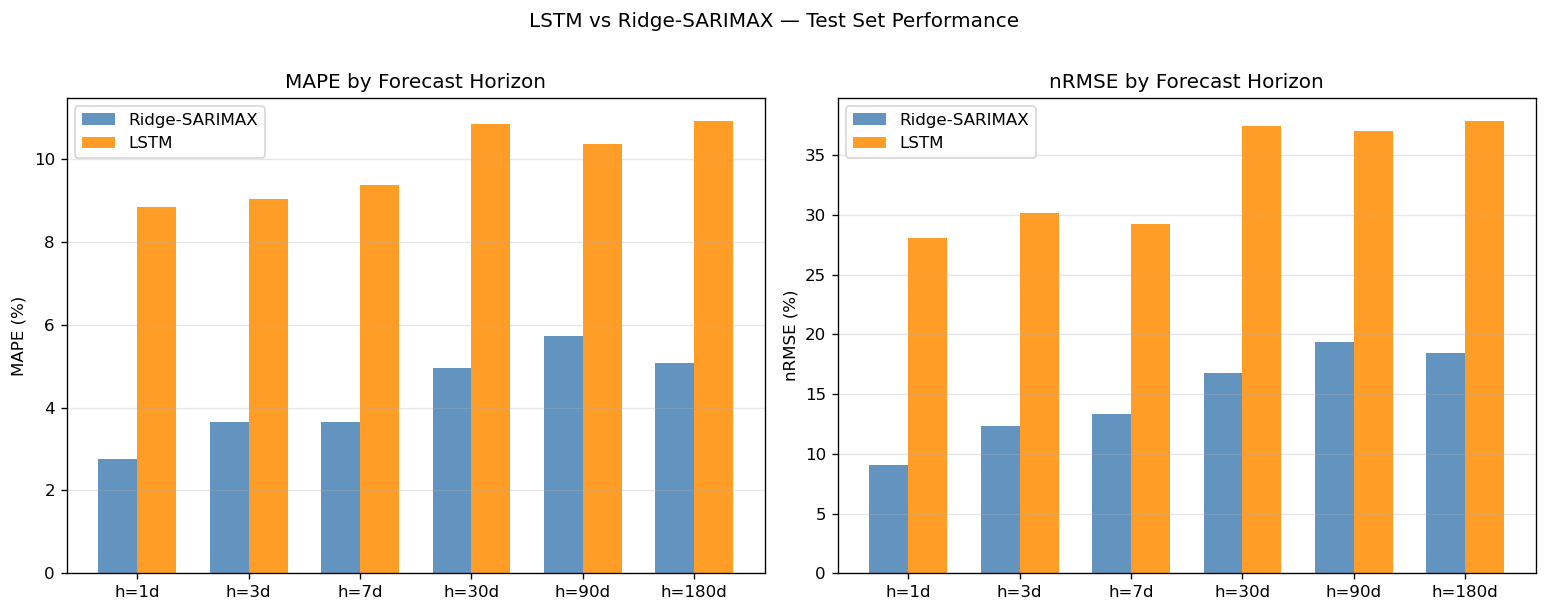

Saved: plots/lstm_vs_sarimax_bars.png


In [14]:
# ── MAPE and nRMSE bar charts ──────────────────────────────────────────────
lstm_mapes    = [lstm_metrics[h]['mape']    for h in HORIZONS]
sarimax_mapes = [sarimax_metrics[h]['mape'] for h in HORIZONS]
lstm_nrmses   = [lstm_metrics[h]['nrmse']   for h in HORIZONS]
sarimax_nrmses= [sarimax_metrics[h]['nrmse'] for h in HORIZONS]

x     = np.arange(len(HORIZONS))
width = 0.35
h_labels = [f'h={h}d' for h in HORIZONS]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, sarx_vals, lstm_vals, ylabel, title in [
    (axes[0], sarimax_mapes,  lstm_mapes,  'MAPE (%)',   'MAPE by Forecast Horizon'),
    (axes[1], sarimax_nrmses, lstm_nrmses, 'nRMSE (%)',  'nRMSE by Forecast Horizon'),
]:
    ax.bar(x - width/2, sarx_vals, width, label='Ridge-SARIMAX',
           color='steelblue',  alpha=0.85)
    ax.bar(x + width/2, lstm_vals, width, label='LSTM',
           color='darkorange', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(h_labels)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('LSTM vs Ridge-SARIMAX — Test Set Performance', y=1.01)
plt.tight_layout()
plt.savefig('plots/lstm_vs_sarimax_bars.png', bbox_inches='tight')
plt.show()
print('Saved: plots/lstm_vs_sarimax_bars.png')

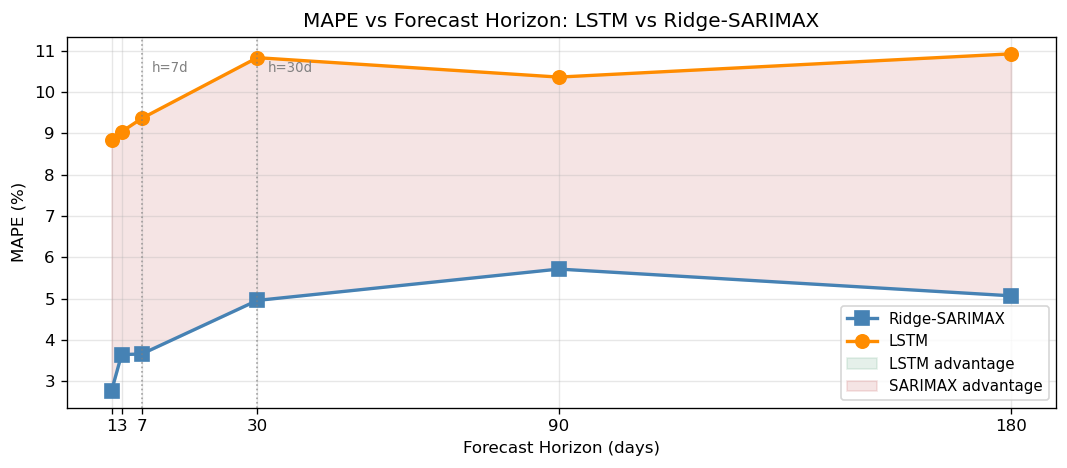

Saved: plots/lstm_mape_vs_horizon.png


In [15]:
# ── MAPE vs Horizon line plot ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(HORIZONS, sarimax_mapes, '-s', color='steelblue',  lw=2, ms=8,
        label='Ridge-SARIMAX')
ax.plot(HORIZONS, lstm_mapes,    '-o', color='darkorange', lw=2, ms=8,
        label='LSTM')

# Shade advantage regions
ax.fill_between(HORIZONS, sarimax_mapes, lstm_mapes,
                where=[s > l for s, l in zip(sarimax_mapes, lstm_mapes)],
                alpha=0.12, color='seagreen', label='LSTM advantage')
ax.fill_between(HORIZONS, sarimax_mapes, lstm_mapes,
                where=[s <= l for s, l in zip(sarimax_mapes, lstm_mapes)],
                alpha=0.12, color='firebrick', label='SARIMAX advantage')

# H3 boundary markers
for xv, lbl in [(7, 'h=7d'), (30, 'h=30d')]:
    ax.axvline(xv, color='gray', lw=1, ls=':', alpha=0.7)
    ax.text(xv + 2, max(max(sarimax_mapes), max(lstm_mapes)) * 0.96,
            lbl, fontsize=8, color='gray')

ax.set_xlabel('Forecast Horizon (days)')
ax.set_ylabel('MAPE (%)')
ax.set_title('MAPE vs Forecast Horizon: LSTM vs Ridge-SARIMAX')
ax.set_xticks(HORIZONS)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/lstm_mape_vs_horizon.png', bbox_inches='tight')
plt.show()
print('Saved: plots/lstm_mape_vs_horizon.png')

In [ ]:
# ── Forecast vs actual — last 90 test days (h=1, LSTM) ────────────────────
print('Generating day-by-day h=1 LSTM predictions (direct)...')

model_1 = lstm_models[1]
model_1.eval()
h1_preds = []

with torch.no_grad():
    for i in range(TEST_SIZE):
        g = TRAIN_SIZE + VAL_SIZE + i
        if g < SEQ_LEN:
            continue
        window  = arr_full[g - SEQ_LEN : g]
        x_t     = torch.FloatTensor(window).unsqueeze(0).to(DEVICE)
        pred_sc = model_1(x_t).item()
        h1_preds.append(float(scaler_y.inverse_transform([[pred_sc]])[0, 0]))

h1_preds   = np.array(h1_preds)
actual_all = y_test_arr[:len(h1_preds)]

PLOT_DAYS  = 90
test_dates = test['date'].values[-PLOT_DAYS:]
pred_tail  = h1_preds[-PLOT_DAYS:]
act_tail   = actual_all[-PLOT_DAYS:]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(test_dates, act_tail,  color='gray',       lw=1.2, alpha=0.9, label='Actual')
ax.plot(test_dates, pred_tail, color='darkorange', lw=1.5, alpha=0.9, label='LSTM (h=1, direct)')
ax.set_xlabel('Date')
ax.set_ylabel('Demand (MW)')
ax.set_title(f'LSTM Forecast vs Actual — Last {PLOT_DAYS} Test Days (h=1, direct)\n'
             f'MAPE = {mape(act_tail, pred_tail):.2f}%')
ax.legend()
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('plots/lstm_forecast_vs_actual.png', bbox_inches='tight')
plt.show()
print('Saved: plots/lstm_forecast_vs_actual.png')

---
## 11 · Save Outputs

In [ ]:
# ── lstm_results.csv  (consumed by notebook 04 H3 section) ────────────────
lstm_results = pd.DataFrame([{
    'horizon_days':  h,
    'mape_pct':      round(lstm_metrics[h]['mape'],  4),
    'nrmse_pct':     round(lstm_metrics[h]['nrmse'], 4),
    'n_eval_points': lstm_metrics[h]['n_eval'],
    'best_epoch':    best_epochs[h],
} for h in HORIZONS])

lstm_results.to_csv('data/lstm_results.csv', index=False)
print('Saved: data/lstm_results.csv')
display(lstm_results)

# ── lstm_dm_tests.csv ─────────────────────────────────────────────────────
dm_save = pd.DataFrame([{
    'horizon_days':     r['Horizon'],
    'lstm_mape_pct':    r['LSTM MAPE (%)'],
    'sarimax_mape_pct': r['Ridge MAPE (%)'],
    'delta_mape':       r['Δ MAPE'],
    'dm_stat':          r['DM stat'],
    'p_value':          r['p-value'],
    'significant_005':  r['Significant'] == '✓',
    'n_eval':           r['n'],
} for _, r in dm_df.iterrows()])

dm_save.to_csv('data/lstm_dm_tests.csv', index=False)
print('\nSaved: data/lstm_dm_tests.csv')
display(dm_save)

# ── File summary ──────────────────────────────────────────────────────────
outputs = (
    ['data/lstm_results.csv', 'data/lstm_dm_tests.csv', 'data/lstm_best.pt']
    + [f'data/lstm_best_h{h}.pt' for h in HORIZONS]
    + ['plots/lstm_training_curves.png', 'plots/lstm_vs_sarimax_bars.png',
       'plots/lstm_mape_vs_horizon.png', 'plots/lstm_forecast_vs_actual.png']
)
print('\nAll outputs:')
for f in outputs:
    if os.path.exists(f):
        print(f'  ✓  {os.path.getsize(f):>8,} bytes  {f}')
    else:
        print(f'  ✗  (missing)              {f}')

---
## Summary

### LSTM Configuration

| Setting | Value |
|---------|-------|
| Architecture | 2-layer LSTM (hidden=128, dropout=0.3) + Dense(1) |
| Lookback | 365 days (full year — captures annual seasonality) |
| Features | demand_MW + 18 exogenous |
| Multi-step | Direct forecasting — one model per horizon |
| Optimiser | Adam, lr=1e-4, weight_decay=1e-4, grad clip=1.0 |
| LR scheduler | ReduceLROnPlateau (factor=0.5, patience=10) |
| Early stopping | Patience 25 on val MSE, max 200 epochs |

### Key changes vs. original baseline

| Issue | Old | Fixed |
|-------|-----|-------|
| Lookback window | 30 days | 365 days |
| Multi-step strategy | Recursive (error compounding) | Direct (one model/horizon) |
| Architecture | hidden=64, dropout=0.2 | hidden=128, dropout=0.3 |
| Optimiser | Adam lr=1e-3, no weight decay | Adam lr=1e-4, weight_decay=1e-4 |
| LR schedule | None | ReduceLROnPlateau |
| Early stopping | patience=10 (stopped@5) | patience=25 |

### Outputs consumed by notebook 04

| File | Contents |
|------|----------|
| `data/lstm_results.csv` | MAPE / nRMSE per horizon |
| `data/lstm_dm_tests.csv` | DM statistics and p-values per horizon |
| `data/lstm_best_h{H}.pt` | Saved model weights per horizon |

### H3 Result

See the Diebold-Mariano table above and `data/lstm_dm_tests.csv`.
Notebook 04, Section H3, loads these files and produces the final hypothesis verdict.